In [47]:
# Read the .csv file and store it in a Pandas DataFrame called df. 
# Have a look at the read_csv() documentation and try to provide these column names: ['DATE', 'TAG', 'POSTS']
import pandas
import matplotlib.pyplot as plt
df = pandas.read_csv('QueryResults.csv', header=0, names=['DATE', 'TAG', 'POSTS'])
df

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124
...,...,...,...
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182


In [48]:
#Look at the first and last 5 rows of the DataFrame.
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124


In [49]:
df.tail()

,DATE,TAG,POSTS
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182
1990,2020-07-01 00:00:00,swift,3607


In [50]:
# How many rows and how many columns does it have?
df.shape

(1991, 3)

In [51]:
# Count the number of entries in each column. (count only of Non-NAN values)
df.count()

DATE     1991
TAG      1991
POSTS    1991
dtype: int64

In [52]:
# The TAG is the name of the programming language. So for example in July 2008, 
# there were 3 posts tagged with the language C#. Given that the TAG serves as 
# our category column, can you figure out how to count the number of posts per 
# language? Which programming language had the most number of posts since the 
# creation of Stack Overflow? (Hint: you may need to review one of yesterday's lessons).
post_per_language = df.groupby('TAG')['POSTS'].sum()
post_per_language.sort_values(ascending=False)

TAG
javascript    2056510
java          1696403
python        1496210
c#            1423530
php           1361988
c++            684210
r              356799
c              336042
swift          273055
ruby           214582
perl            65286
go              47499
delphi          46212
assembly        34852
Name: POSTS, dtype: int64

In [53]:
# Also, some languages are older like C and other languages are newer (like Swift). 
# The dataset starts in July 2008, so some languages will not have any posts for every month. 
# Can you count how many months of posts exist for each programming language?

df.groupby('TAG').count()

,DATE,POSTS
TAG,,
assembly,144,144
c,144,144
c#,145,145
c++,144,144
delphi,144,144
go,129,129
java,144,144
javascript,144,144
perl,144,144


In [54]:
# Alternatively, for column names no spaces, we can also use the dot-notation:
df['DATE'][1]
df.DATE[1]

'2008-08-01 00:00:00'

In [55]:
# type of date is str... we're to change that type of data
type(df.DATE[1])

str

In [56]:
# Convert the string data into date time obj
type(df.DATE[1]) # str
df.DATE = pandas.to_datetime(df.DATE)
type(df.DATE)
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


In [57]:
# Can you pivot the df DataFrame so that each row is a date and each column is a 
# programming language? 
# Store the result under a variable called reshaped_df_df. 
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped_df.head()
reshaped_df.columns


Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')

In [58]:
# Examine the dimensions of the reshaped DataFrame. How many rows does it have? 
# How many columns?
reshaped_df.shape

(145, 14)

In [59]:
# Examine the head and the tail of the DataFrame. What does it look like?
print(f'head: {reshaped_df.head()}')
print(f'tail: {reshaped_df.tail()}')

head: TAG         assembly      c      c#    c++  delphi  go    java  javascript  \
DATE                                                                         
2008-07-01       NaN    NaN     3.0    NaN     NaN NaN     NaN         NaN   
2008-08-01       8.0   85.0   511.0  164.0    14.0 NaN   222.0       162.0   
2008-09-01      28.0  321.0  1649.0  755.0   105.0 NaN  1137.0       640.0   
2008-10-01      15.0  303.0  1989.0  811.0   112.0 NaN  1153.0       725.0   
2008-11-01      17.0  259.0  1730.0  735.0   141.0 NaN   958.0       579.0   

TAG          perl    php  python    r   ruby  swift  
DATE                                                 
2008-07-01    NaN    NaN     NaN  NaN    NaN    NaN  
2008-08-01   28.0  161.0   124.0  NaN   73.0    NaN  
2008-09-01  131.0  482.0   542.0  6.0  290.0    NaN  
2008-10-01  127.0  617.0   510.0  NaN  249.0    NaN  
2008-11-01   97.0  504.0   452.0  1.0  160.0    NaN  
tail: TAG         assembly       c       c#     c++  delphi     go   

In [60]:
# Print out the column names.
reshaped_df.columns


Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')

In [61]:
# Count the number of entries per column.
reshaped_df.count()

TAG
assembly      144
c             144
c#            145
c++           144
delphi        144
go            129
java          144
javascript    144
perl          144
php           144
python        144
r             142
ruby          144
swift         135
dtype: int64

In [62]:
# Count the total of posts per programming language.
for col in reshaped_df.columns:
    print(f'programming language: {col}, total posts: {reshaped_df[col].sum()}')

programming language: assembly, total posts: 34852.0
programming language: c, total posts: 336042.0
programming language: c#, total posts: 1423530.0
programming language: c++, total posts: 684210.0
programming language: delphi, total posts: 46212.0
programming language: go, total posts: 47499.0
programming language: java, total posts: 1696403.0
programming language: javascript, total posts: 2056510.0
programming language: perl, total posts: 65286.0
programming language: php, total posts: 1361988.0
programming language: python, total posts: 1496210.0
programming language: r, total posts: 356799.0
programming language: ruby, total posts: 214582.0
programming language: swift, total posts: 273055.0


In [63]:
# When we count the number of entries per column we see that not all languages are the same. 
# The reason is that the .count() method excludes NaN values. 
# When we pivoted the DataFrame the NaN values were inserted when there were no posts for a language in that month
# In this case, we don't want to drop the rows that have a NaN value. 
# Instead, we want to substitute the number 0 for each NaN value in the DataFrame. 
# We can do this with the .fillna() method.

reshaped_df.fillna(0, inplace=True)
reshaped_df.count()

TAG
assembly      145
c             145
c#            145
c++           145
delphi        145
go            145
java          145
javascript    145
perl          145
php           145
python        145
r             145
ruby          145
swift         145
dtype: int64

In [64]:
# Here we are using the .isna() method that we've used before, but we're chaining two more things: 
# the values attribute and the any() method. This means we don't have to search through the entire 
# DataFrame to spot if .isna() is True.
reshaped_df.isna().values.any()

np.False_

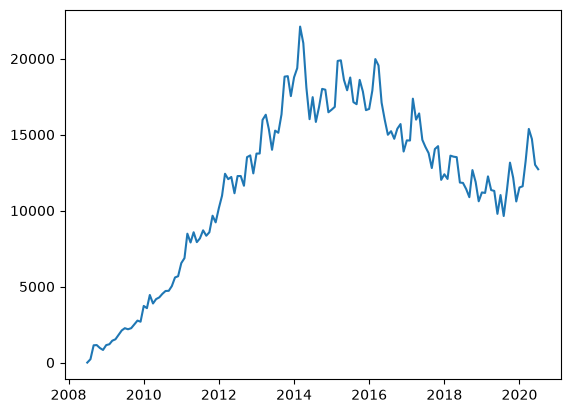

In [69]:
# You can actually show a line chart for the popularity of a programming 
# language using only a single line of code. Can you use the .plot() 
# documentation to figure out how to do this? Try and plot the popularity 
# of the Java programming language. Here's what you're aiming for:

# chart = plt(reshaped_df.java)
reshaped_df.head()
reshaped_df.java
plt.plot(reshaped_df.index, reshaped_df.java)


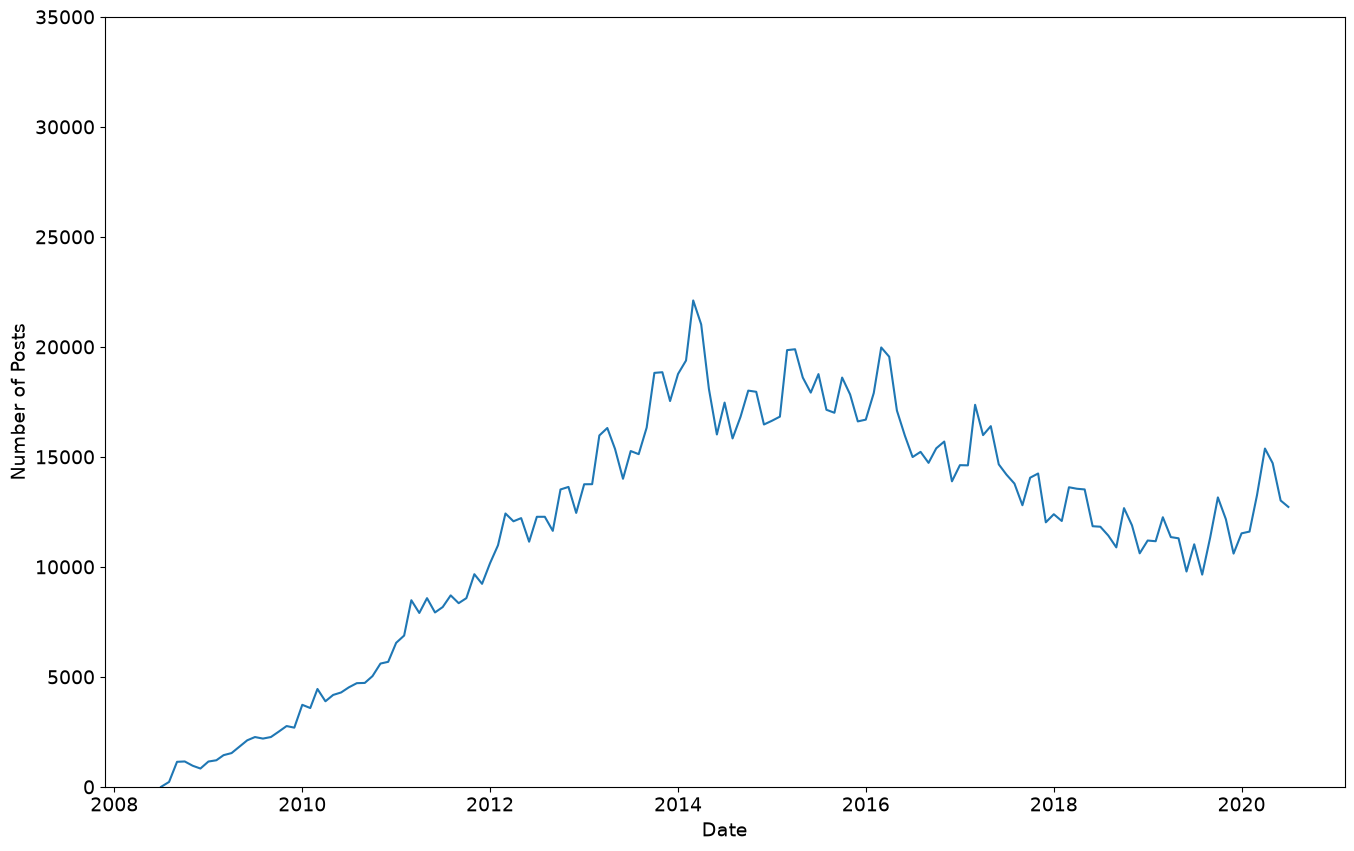

In [71]:
# To make our chart larger we can provide a width (16) and a height (10) as the figsize of the figure.
plt.figure(figsize=(16, 10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Now we can add labels. Also, we're never going to get less than 0 posts, so let's set a lower limit of 0 
# for the y-axis with .ylim().
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35_000)

# Make it a chart
plt.plot(reshaped_df.index, reshaped_df.java)

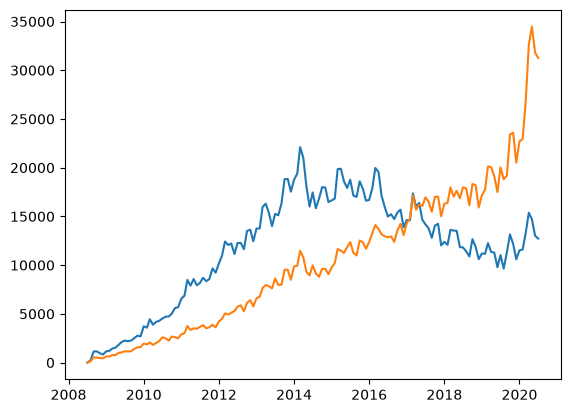

In [76]:
# Now that you've successfully created and styled your chart, can you figure out 
# how to plot both Java and Python next to each other?
plt.plot(reshaped_df.index, reshaped_df.java)
plt.plot(reshaped_df.index, reshaped_df.python)

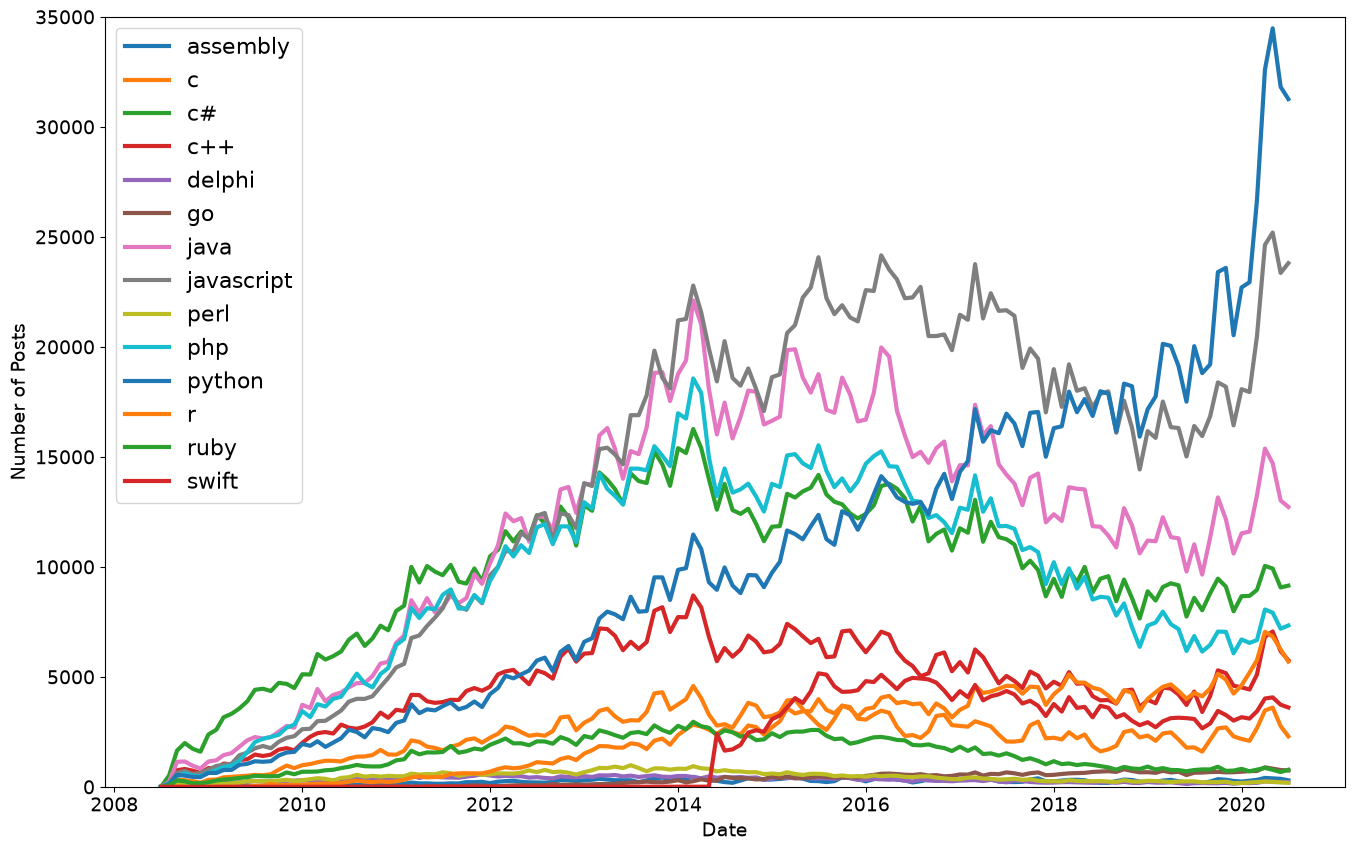

In [ ]:
# But what if we wanted to plot all the programming languages on the 
# same chart? We don't want to type out .plot() a million times, right? 
# We can actually just use a for-loop:

plt.figure(figsize=(16, 10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35_000)

# Modify the line's thick and the name of the programming language
for col in reshaped_df.columns:
    plt.plot(reshaped_df.index, 
             reshaped_df[col],
             linewidth=3,
             label=reshaped_df[col].name)

plt.legend(fontsize=16)

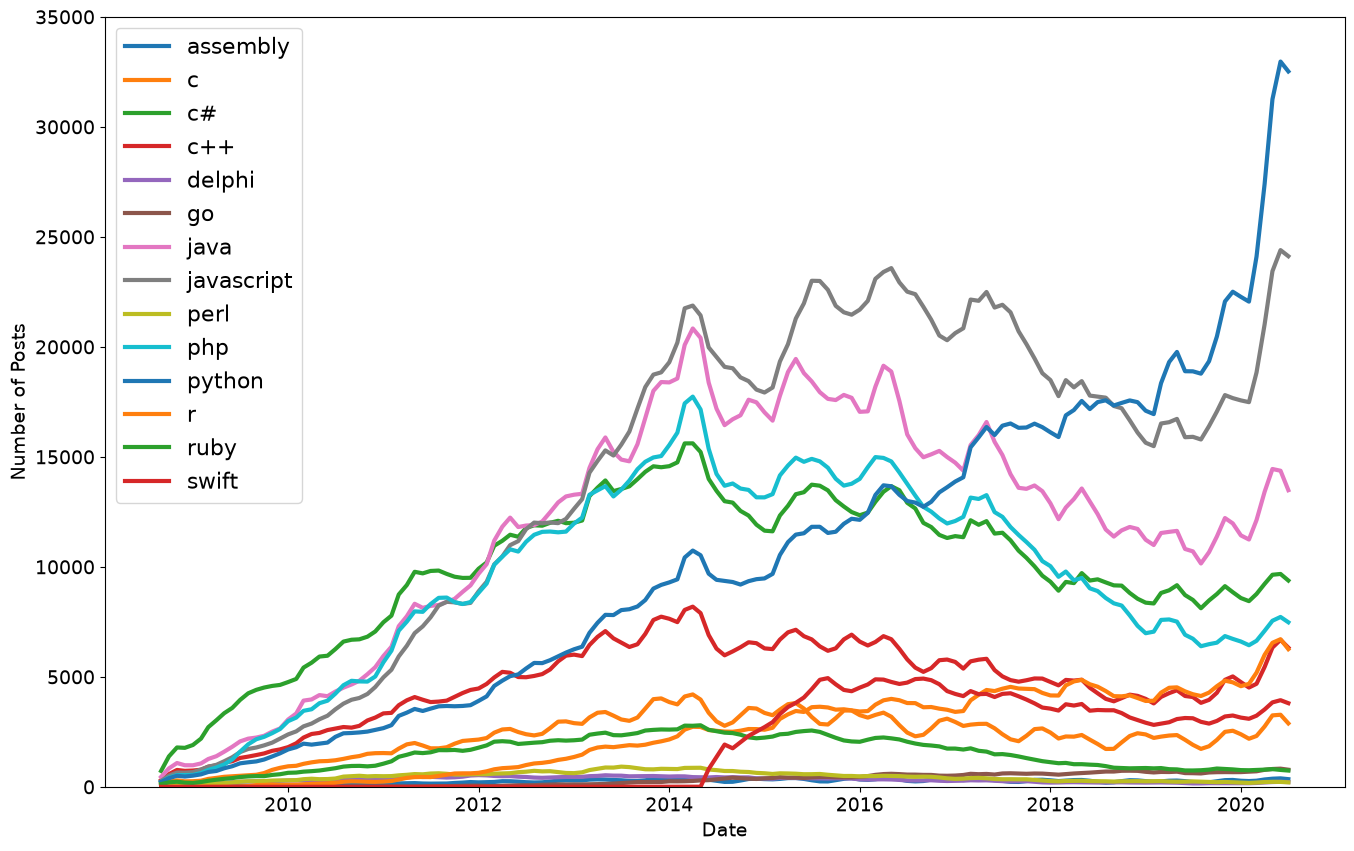

In [ ]:
# Looking at our chart we see that time-series data can be quite noisy, with a lot of 
# up and down spikes. This can sometimes make it difficult to see what's going on.
# A useful technique to make a trend apparent is to smooth out the observations 
# by taking an average. By averaging say, 6 or 12 observations we can construct 
# something called the rolling mean. Essentially we calculate the average in a 
# window of time and move it forward by one observation at a time.

# 3 observations, change to 6 or 12 to play with it a little bit
roll_df = reshaped_df.rolling(window=3).mean()

plt.figure(figsize=(16, 10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35_000)

for col in roll_df.columns:
    plt.plot(roll_df.index, 
             roll_df[col],
             linewidth=3,
             label=roll_df[col].name)

plt.legend(fontsize=16)


In [122]:
# Understanding groupby
res = reshaped_df.groupby('DATE')[['java', 'python']]
res.head()

TAG,java,python
DATE,,
2008-07-01,0.0,0.0
2008-08-01,222.0,124.0
2008-09-01,1137.0,542.0
2008-10-01,1153.0,510.0
2008-11-01,958.0,452.0
...,...,...
2020-03-01,13253.0,26673.0
2020-04-01,15377.0,32605.0
2020-05-01,14711.0,34478.0
